# Energy-Based Transformers - A Simple Coding Tutorial #

In this tutorial our goal will be to implement a small EBT that learns an energy function $E_\theta(x, \hat{y})$ and "thinks" by iteratively refining candidate prediction $\hat{y}$ using *gradient descent* steps on the prediction embeddings.

We will use 'PyTorch' and optimize continuous embeddings for candidate predictions (avoid discrete search), and perform both training and inference.

In [ ]:
# INSTALL LIBRARIES IF NECESSARY:)
#pip install torch tqdm matplotlib


In [ ]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import math, random
import matplotlib.pyplot as plt


## 1) Intuition - Short Recap ##

* Energy Function: As we know, EBTs learn $E_\theta(x, \hat{y})$. Low energy = a good answer $\hat{y}$ for every input x.

* Optimization-as-thinking: at inference time the model starts with a random $\hat{y_0}$ (continuous embedding) and update with gradient descent:

$$\hat{y_{t+1}} = \hat{y_t} - \alpha \nabla_{\hat{y_t}} E_{\theta} (x, \hat{y_t})$$

Each step is like a short thought that reduces energy (i.e. increases compatibility of the candidate output).

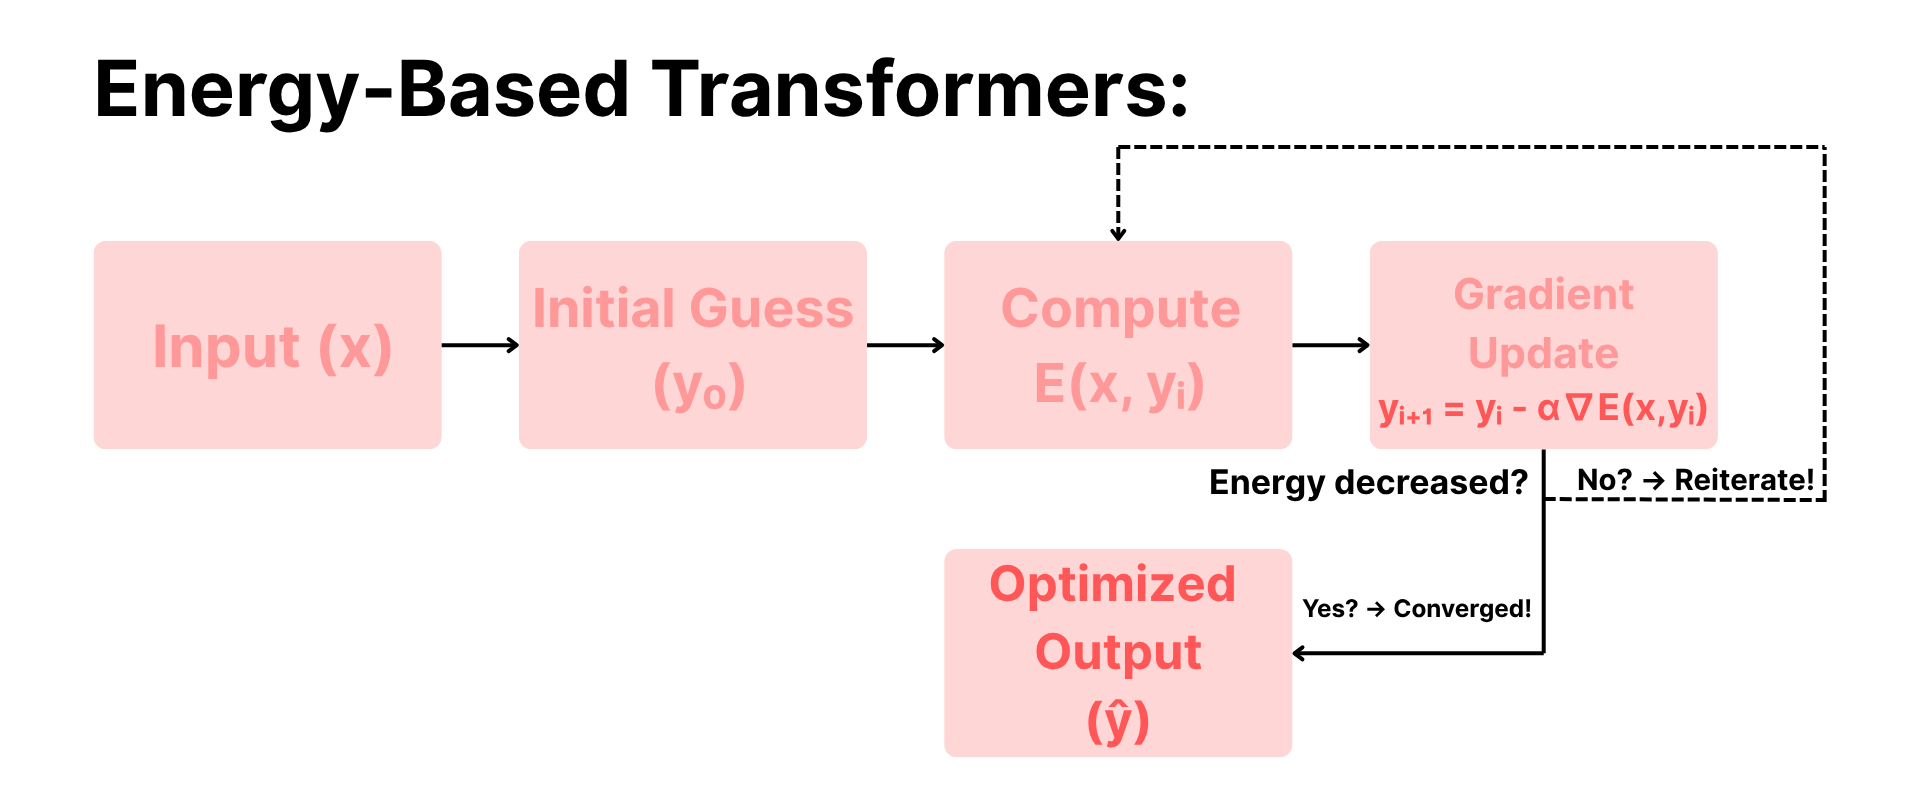


* Optimization in embedding space lets us use gradient-based methods.

We will implement a small transformer style energy network that scores candidate embeddings conditioned on a short context.



## 2) Small synthetic data and tokenization ##

We will use very small strings so that the training can be fast and interpretable.

In [ ]:
# tiny set of short strings
SENTENCES = [
    "help", "hell", "heap", "hero", "good", "goof", "gala",
    "have", "hate", "hola", "hope", "home", "hand"
]

# simple char tokenizer (maps characters -> ints)
class SimpleTokenizer:
    def __init__(self, corpus):
        chars = sorted({c for s in corpus for c in s})
        self.ch2i = {c:i+1 for i,c in enumerate(chars)}
        self.i2ch = {i:c for c,i in self.ch2i.items()}
        self.vocab_size = len(self.ch2i) + 1
    def encode(self, s):
        return [self.ch2i[c] for c in s if c in self.ch2i]
    def decode(self, idx):
        return self.i2ch.get(idx, '?')

tokenizer = SimpleTokenizer(SENTENCES)
tokenizer.vocab_size, tokenizer.ch2i


(15,
 {'a': 1,
  'd': 2,
  'e': 3,
  'f': 4,
  'g': 5,
  'h': 6,
  'l': 7,
  'm': 8,
  'n': 9,
  'o': 10,
  'p': 11,
  'r': 12,
  't': 13,
  'v': 14})

## 3) Dataset class: context -> next char ##

We will try to predict the next character given a fixed-length context (prefix). Context length = 3 to keep the training simple.

In [ ]:
class ToyNextCharDataset(Dataset):
    def __init__(self, sentences, tokenizer, ctx_len=3):
        self.toks = [tokenizer.encode(s) for s in sentences]
        self.ctx_len = ctx_len
    def __len__(self): return len(self.toks)
    def __getitem__(self, idx):
        t = self.toks[idx]
        ctx = t[:self.ctx_len]
        # pad context
        if len(ctx) < self.ctx_len:
            ctx = ctx + [0]*(self.ctx_len - len(ctx))
        # target = next char if exists else PAD(0)
        target = t[self.ctx_len] if len(t) > self.ctx_len else 0
        return torch.tensor(ctx, dtype=torch.long), torch.tensor(target, dtype=torch.long)

ds = ToyNextCharDataset(SENTENCES, tokenizer, ctx_len=3)
dl = DataLoader(ds, batch_size=4, shuffle=True)


Therefore, our simple prediction task is: given 3 chars, predict the 4th char.

## 4) A small and clear EBT Model ##

We will now create our required simple EBT model

Model pieces:
* Embeddings for context tokens
* Small TransformerEncoder to build context representation
* The energy head: mapping combined context+candidate to scalar energy per candidate token position
* A linear head to map candidate embeddings -> logits (for loss)

We will use a minimal TransformerEncoder like block from PyTorch (nn.TransformerEncoderLayer).

In [ ]:
class TinyEBT(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, nlayer=1, ctx_len=3):
        super().__init__()
        self.ctx_len = ctx_len
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=4*d_model, activation='relu')
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=nlayer)
        # energy MLP maps token output -> scalar energy (per predicted token position)
        self.energy_head = nn.Sequential(
            nn.Linear(d_model, d_model//2),
            nn.ReLU(),
            nn.Linear(d_model//2, 1)
        )
        # map embedding back to logits for token classification
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward_energy(self, ctx_ids, pred_embs):
        """
        ctx_ids: (B, ctx_len)
        pred_embs: (B, pred_len, d_model)  # our optimization variables
        returns: energies per token (B, pred_len)
        """
        B = ctx_ids.size(0)
        ctx_emb = self.embed(ctx_ids)  # (B, ctx_len, d)
        # concat: context then predicted embeddings
        seq = torch.cat([ctx_emb, pred_embs], dim=1)  # (B, S, d)
        # transformer expects (S,B,d)
        out = self.transformer(seq.transpose(0,1)).transpose(0,1)
        # take outputs corresponding to predicted positions (last pred_len)
        pred_out = out[:, self.ctx_len:, :]  # (B, pred_len, d)
        energies = self.energy_head(pred_out).squeeze(-1)  # (B, pred_len)
        return energies

    def logits_from_emb(self, pred_embs):
        return self.lm_head(pred_embs)  # (B, pred_len, V)


The transformer conditions predict position on context and predict embeddings jointly. The energy head scores how plausible each predicted token is. And finally logits let us compute a *cross-entropy* loss when comparing finl prediction to ground-truth.

## 5) Prediction Embeddings: Initialization and Optimization loop ##

For now, we will restric prediciton length to 1 (i.e. predict a single next token). Each candidate is a small bector of dimension 'd_model'. And then we will do a gradient-based optimization on these vectors.

Two modes:
* **S1 (Fast)**: Detach embeddings between inner steps i.e. do not backpropagates through the inner optimization. This is stable and computationally cheaper.

* **S2 (Full)**: Backpropagation through the inner optimization loops (this is mor epowerful and can be memory-heavy).

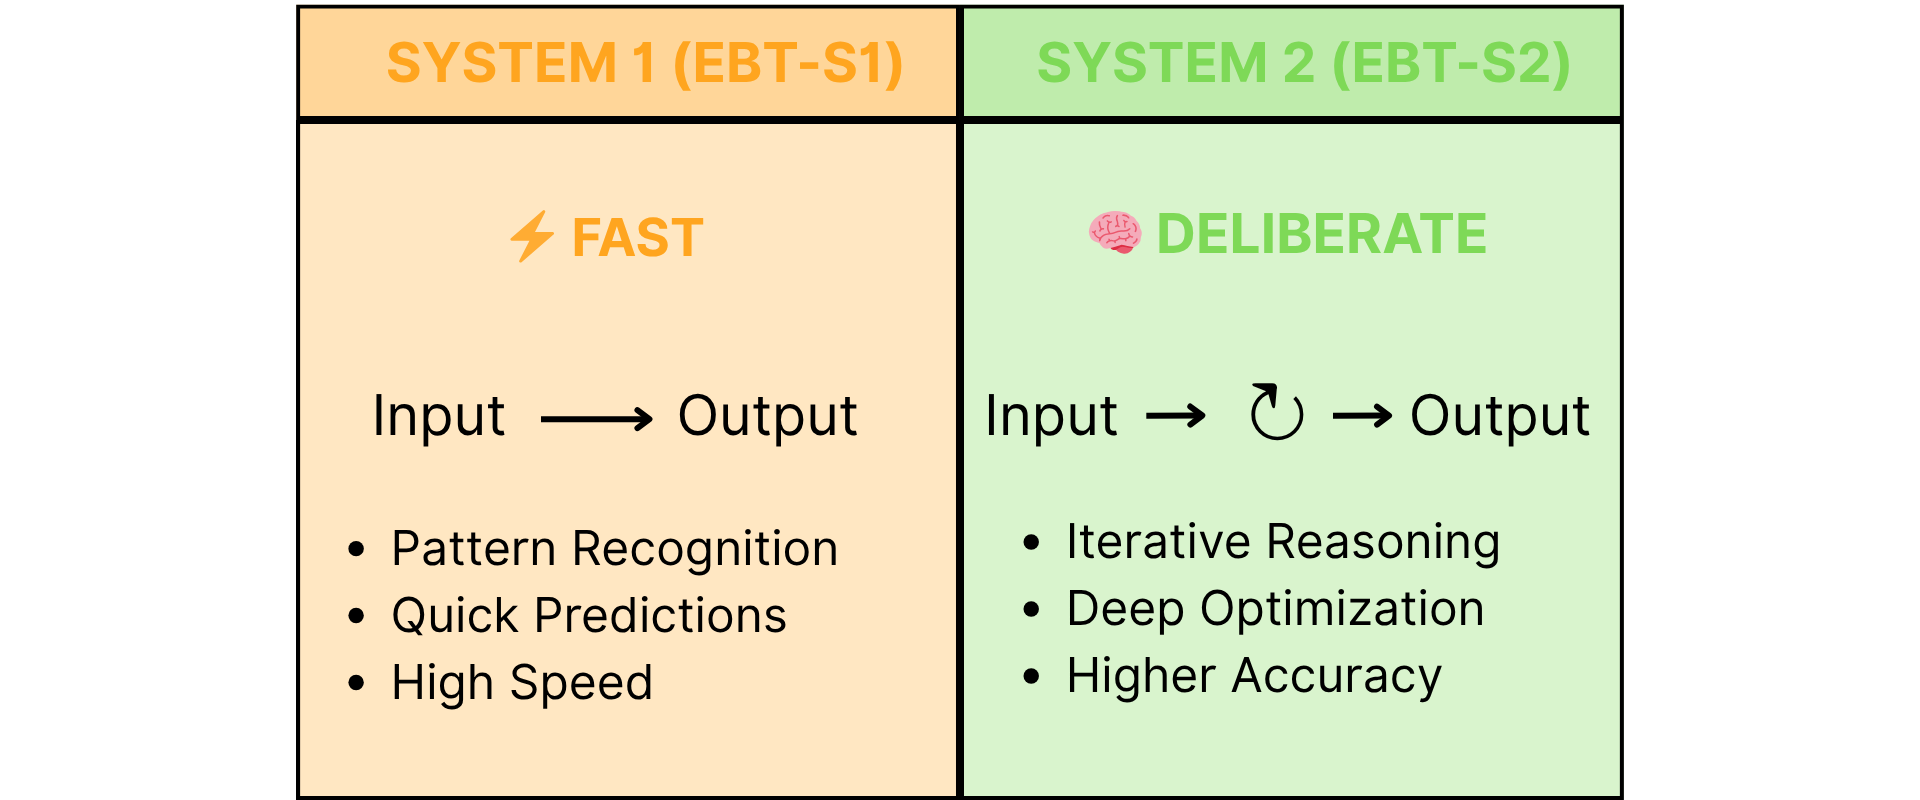

Now lets implement the optimization (the "thinking" loop): We will perform training with the S1 mode and then try S2 mode.


In [ ]:
def init_pred_embs(B, pred_len, d_model, device, scale=0.1):
    return torch.randn(B, pred_len, d_model, device=device) * scale

def inner_optimize(model, ctx_ids, pred_embs, steps=5, alpha=0.5, detach_between_steps=True):
    """
    pred_embs: torch tensor (B, pred_len, d), initially detached
    returns final_pred_embs (B, pred_len, d), energies_history (list)
    """
    energies_hist = []
    for i in range(steps):
        pred_embs.requires_grad_(True)
        energies = model.forward_energy(ctx_ids, pred_embs)  # (B, pred_len)
        E = energies.sum()  # scalar across batch and positions
        # gradient of E wrt pred_embs
        grads = torch.autograd.grad(E, pred_embs, create_graph=(not detach_between_steps))[0]
        # step: reduce energy
        pred_embs = pred_embs - alpha * grads
        if detach_between_steps:
            pred_embs = pred_embs.detach()
        energies_hist.append(energies.detach().cpu())
    return pred_embs, energies_hist


'torch.autograd.grad' gives gradients w.r.t the predicted embeddings (the variables we are optimizing). 'detach_between_steps=True' enforces S1 Mode.

## 6) Loss, training loop and S1 vs S2 choice ##

After 'N' inner steps we map final embeddings to logits and compute cross-entropy loss against the true next token.

As mentioned the training loop below first uses S1 (more stable). Later we set 'detach_between_steps=False' to try S2 mode.

In [ ]:
def train_ebt(model, dataloader, device='cpu', epochs=20, inner_steps=6, alpha=0.5, s2=False):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for ctx_ids, target in dataloader:
            ctx_ids = ctx_ids.to(device)
            target = target.to(device)
            B = ctx_ids.size(0)
            pred_embs = init_pred_embs(B, 1, model.embed.embedding_dim, device)
            pred_final, energies_hist = inner_optimize(model, ctx_ids, pred_embs,
                                                       steps=inner_steps, alpha=alpha,
                                                       detach_between_steps=(not s2))
            # compute logits and loss
            logits = model.logits_from_emb(pred_final).squeeze(1)  # (B, V)
            loss = F.cross_entropy(logits, target)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * B
        print(f"Epoch {ep+1}/{epochs}  avg_loss={total_loss/len(dataloader.dataset):.4f}")


The training operation updates model parameters(energy network weights). The inner optimization is part of the forward computation but in S1 we do not backprop through the inner loop of the network.

## 7) Inference: multiple starts + choosing  lowest energy ##

At inference we do multiple starts and pick the candidate with lowest energy (this is verification/best-of-N).

In [ ]:
def infer(model, ctx_str, tokenizer, device='cpu', n_starts=8, inner_steps=8, alpha=0.4):
    model.eval()
    ctx_toks = tokenizer.encode(ctx_str)
    ctx_len = model.ctx_len
    ctx_ids = (ctx_toks[:ctx_len] + [0]*(ctx_len - len(ctx_toks))) if len(ctx_toks) < ctx_len else ctx_toks[:ctx_len]
    ctx_ids = torch.tensor([ctx_ids], dtype=torch.long, device=device)
    best = None
    best_energy = float('inf')
    for _ in range(n_starts):
        pred_emb = init_pred_embs(1, 1, model.embed.embedding_dim, device)
        pred_final, _ = inner_optimize(model, ctx_ids, pred_emb, steps=inner_steps, alpha=alpha, detach_between_steps=False)
        # compute energy scalar and logits
        energies = model.forward_energy(ctx_ids, pred_final).sum(dim=1)  # (1,)
        energy_val = energies.item()
        logits = model.logits_from_emb(pred_final).squeeze(1)  # (1,V)
        token = logits.argmax(dim=-1).item()
        if energy_val < best_energy:
            best_energy = energy_val
            best = token
    return tokenizer.decode(best), best_energy


Multiple random starts avoid poor local minima and selecting by energy chooses the most compatible candidate.

## 8) Training: Now we assemble everything and train our network ##

* The best result was achieved by training for around 2000 Epochs.

In [ ]:
# assemble dataset and model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
ds = ToyNextCharDataset(SENTENCES, tokenizer, ctx_len=3)
dl = DataLoader(ds, batch_size=4, shuffle=True)
model = TinyEBT(tokenizer.vocab_size, d_model=64, nhead=4, nlayer=1, ctx_len=3)

# train (S1 mode - detach inner steps)
train_ebt(model, dl, device=device, epochs=2000, inner_steps=6, alpha=0.5, s2=False)



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/2000  avg_loss=2.7079
Epoch 2/2000  avg_loss=2.7223
Epoch 3/2000  avg_loss=2.6710
Epoch 4/2000  avg_loss=2.6888
Epoch 5/2000  avg_loss=2.6665
Epoch 6/2000  avg_loss=2.6815
Epoch 7/2000  avg_loss=2.6228
Epoch 8/2000  avg_loss=2.6216
Epoch 9/2000  avg_loss=2.6188
Epoch 10/2000  avg_loss=2.6316
Epoch 11/2000  avg_loss=2.6271
Epoch 12/2000  avg_loss=2.6076
Epoch 13/2000  avg_loss=2.5746
Epoch 14/2000  avg_loss=2.5802
Epoch 15/2000  avg_loss=2.5994
Epoch 16/2000  avg_loss=2.5762
Epoch 17/2000  avg_loss=2.5829
Epoch 18/2000  avg_loss=2.5763
Epoch 19/2000  avg_loss=2.5527
Epoch 20/2000  avg_loss=2.5360
Epoch 21/2000  avg_loss=2.5274
Epoch 22/2000  avg_loss=2.5367
Epoch 23/2000  avg_loss=2.5280
Epoch 24/2000  avg_loss=2.4924
Epoch 25/2000  avg_loss=2.4936
Epoch 26/2000  avg_loss=2.4662
Epoch 27/2000  avg_loss=2.4805
Epoch 28/2000  avg_loss=2.4740
Epoch 29/2000  avg_loss=2.4566
Epoch 30/2000  avg_loss=2.4293
Epoch 31/2000  avg_loss=2.4352
Epoch 32/2000  avg_loss=2.4399
Epoch 33/2000  av

## 9) Predictions: Inference ##

Next we make predictions:

In [ ]:
# inference examples
for ctx in ["hel", "goo", "hom", "hop", "hav"]:
    pred_char, e = infer(model, ctx, tokenizer, device=device, n_starts=12, inner_steps=8, alpha=0.4)
    print(f"context='{ctx}' -> predicted next char: '{pred_char}' (energy={e:.3f})")


context='hel' -> predicted next char: 'p' (energy=-0.915)
context='goo' -> predicted next char: 'f' (energy=-1.363)
context='hom' -> predicted next char: 'e' (energy=-1.333)
context='hop' -> predicted next char: 'e' (energy=-1.392)
context='hav' -> predicted next char: 'e' (energy=-1.020)


As you can see we got really goot results form our trained network!

Now we can try using S2 mode and you will notice that with backprop the loss decreases much faster, the network learns quicker.

In [ ]:
# assemble dataset and model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
ds = ToyNextCharDataset(SENTENCES, tokenizer, ctx_len=3)
dl = DataLoader(ds, batch_size=4, shuffle=True)
model = TinyEBT(tokenizer.vocab_size, d_model=64, nhead=4, nlayer=1, ctx_len=3)

# train (S2 mode - set to 'True')
train_ebt(model, dl, device=device, epochs=2000, inner_steps=6, alpha=0.5, s2=True)



Epoch 1/2000  avg_loss=2.6143
Epoch 2/2000  avg_loss=2.5209
Epoch 3/2000  avg_loss=2.4361
Epoch 4/2000  avg_loss=2.3885
Epoch 5/2000  avg_loss=2.3083
Epoch 6/2000  avg_loss=2.3089
Epoch 7/2000  avg_loss=2.2181
Epoch 8/2000  avg_loss=2.2431
Epoch 9/2000  avg_loss=2.1905
Epoch 10/2000  avg_loss=2.1253
Epoch 11/2000  avg_loss=2.1306
Epoch 12/2000  avg_loss=2.0020
Epoch 13/2000  avg_loss=1.9900
Epoch 14/2000  avg_loss=1.9952
Epoch 15/2000  avg_loss=1.9199
Epoch 16/2000  avg_loss=1.8870
Epoch 17/2000  avg_loss=1.8096
Epoch 18/2000  avg_loss=1.8596
Epoch 19/2000  avg_loss=1.8133
Epoch 20/2000  avg_loss=1.6592
Epoch 21/2000  avg_loss=1.7388
Epoch 22/2000  avg_loss=1.6513
Epoch 23/2000  avg_loss=1.6164
Epoch 24/2000  avg_loss=1.6089
Epoch 25/2000  avg_loss=1.5217
Epoch 26/2000  avg_loss=1.4900
Epoch 27/2000  avg_loss=1.4832
Epoch 28/2000  avg_loss=1.4364
Epoch 29/2000  avg_loss=1.3581
Epoch 30/2000  avg_loss=1.3369
Epoch 31/2000  avg_loss=1.3270
Epoch 32/2000  avg_loss=1.2417
Epoch 33/2000  av

Make prediction with S2:

In [ ]:
# inference examples
for ctx in ["hel", "goo", "hom", "hop", "hav"]:
    pred_char, e = infer(model, ctx, tokenizer, device=device, n_starts=12, inner_steps=8, alpha=0.4)
    print(f"context='{ctx}' -> predicted next char: '{pred_char}' (energy={e:.3f})")


context='hel' -> predicted next char: 'p' (energy=-21.121)
context='goo' -> predicted next char: 'd' (energy=-15.976)
context='hom' -> predicted next char: 'e' (energy=-22.417)
context='hop' -> predicted next char: 'e' (energy=-22.058)
context='hav' -> predicted next char: 'e' (energy=-22.908)


As you can see above, we have similarly very good results, but as the loss decreased much faster we can also train the network with less number of Epochs. Feel free to change the value in the code and experiment.

You can also experiment with the value of $\alpha$ i.e the learning rate and see how the results and change in loss differ:)

Finally we can also take a look at the history of energy descent from our training with the following plot:

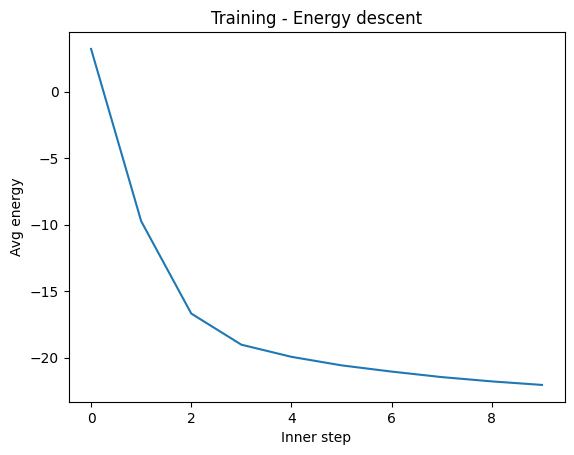

In [ ]:
# collect energies for a single batch run
ctx_ids, target = next(iter(dl))
ctx_ids = ctx_ids.to(device)
pred_emb = init_pred_embs(ctx_ids.size(0), 1, model.embed.embedding_dim, device)
pred_final, energies_hist = inner_optimize(model, ctx_ids, pred_emb, steps=10, alpha=0.4, detach_between_steps=True)
# energies_hist is list of (B, pred_len)
import numpy as np
hist = np.stack([h.mean().numpy() for h in energies_hist])
plt.plot(hist); plt.xlabel('Inner step'); plt.ylabel('Avg energy'); plt.title('Training - Energy descent'); plt.show()
